✅ FIXED METRIC DEPTH (Using fast forward pass only)
Sky region (top-left) valid pixels: 2500 out of 2500
  -> Depths are now: 8.91 to 76.01m (if valid)
  -> Invalid pixels are set to infinity (ignored)

Ground region (bottom-right) valid pixels: 10000 out of 10000
  -> Depths are now: 4.41 to 5.08 meters
  -> Average ground depth: 4.72 meters


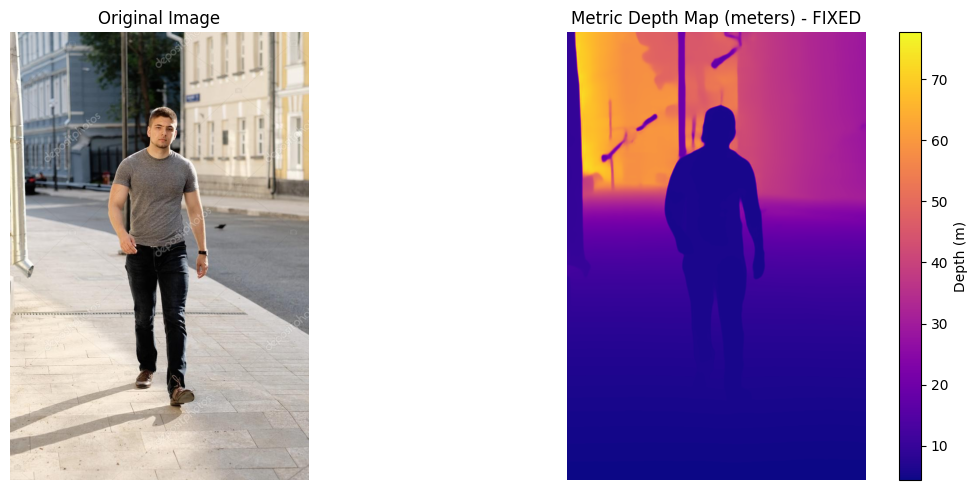

In [1]:
import cv2
import torch
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.getcwd()))

from moge.model.v2 import MoGeModel
# IMPORT the shift recovery function (it's fast and already in your codebase)
from moge.utils.geometry_torch import recover_focal_shift

device = torch.device("cpu")
model = MoGeModel.from_pretrained("/Users/rzt/Documents/env2/annyfit/moge/model.pt").to(device)

# Read image
input_image = cv2.cvtColor(cv2.imread("/Users/rzt/Documents/env1/annyfit/p1.jpg"), cv2.COLOR_BGR2RGB)
input_image = torch.tensor(input_image / 255, dtype=torch.float32, device=device).permute(2, 0, 1)

# =================================================
# 1. FAST FORWARD PASS (No infer() here)
# =================================================
num_tokens = 1200  # Keep it fast
output = model.forward(input_image.unsqueeze(0), num_tokens=num_tokens)

# Extract raw outputs
points_raw = output['points']       # Shape: (1, H, W, 3)
mask_logits = output['mask']        # Shape: (1, H, W)
metric_scale = output['metric_scale']  # Shape: (1,)

# Convert to float for math
points = points_raw.float()
mask = mask_logits.float()
scale = metric_scale.float()

# =================================================
# 2. FAST POST-PROCESSING (Manual, no infer loop)
# =================================================
# A. Create binary mask (threshold 0.5)
mask_binary = mask > 0.5

# B. Recover the "shift" and "focal" from the raw points (Fast math!)
#    This fixes the "sky is 0.96m" issue by shifting Z forward.
focal, shift = recover_focal_shift(points, mask_binary)

# C. Apply the shift to the Z-axis (makes distances positive and correct)
points[..., 2] += shift[..., None, None]
mask_binary &= points[..., 2] > 0  

# D. Apply the metric scale (converts to real meters)
points *= scale[:, None, None, None]

# E. Apply the mask (Invalid pixels become infinity, so they are ignored)
points = torch.where(mask_binary[..., None], points, torch.inf)

# F. Extract the final metric depth
depth = points[..., 2]  # Shape: (1, H, W)

# =================================================
# 3. VERIFY THE FIXED DEPTHS
# =================================================
points_np = points[0].detach().cpu().numpy()
depth_np = depth[0].detach().cpu().numpy()
mask_np = mask_binary[0].detach().cpu().numpy()

# Sky region (Top-left) - Should be mostly INF (masked out)
sky_depths = depth_np[0:50, 0:50]
sky_valid = mask_np[0:50, 0:50]

# Ground region (Bottom-right) - Should have real distances
ground_depths = depth_np[-100:, -100:]
ground_valid = mask_np[-100:, -100:]

print("=" * 50)
print("✅ FIXED METRIC DEPTH (Using fast forward pass only)")
print("=" * 50)
print(f"Sky region (top-left) valid pixels: {sky_valid.sum()} out of {sky_valid.size}")
print(f"  -> Depths are now: {sky_depths[sky_valid].min():.2f} to {sky_depths[sky_valid].max():.2f}m (if valid)")
print(f"  -> Invalid pixels are set to infinity (ignored)")

print(f"\nGround region (bottom-right) valid pixels: {ground_valid.sum()} out of {ground_valid.size}")
print(f"  -> Depths are now: {ground_depths[ground_valid].min():.2f} to {ground_depths[ground_valid].max():.2f} meters")
print(f"  -> Average ground depth: {ground_depths[ground_valid].mean():.2f} meters")

# =================================================
# 4. VISUALIZE (Fast matplotlib)
# =================================================
depth_masked = np.where(mask_np, depth_np, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(input_image.permute(1, 2, 0).cpu().numpy())
axes[0].set_title('Original Image')
axes[0].axis('off')

im = axes[1].imshow(depth_masked, cmap='plasma')
axes[1].set_title('Metric Depth Map (meters) - FIXED')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='Depth (m)')

plt.tight_layout()
plt.show()